In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv"),
date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv"),
sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv"),
booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv"),
cinePOS_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv"),
cinePOS_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv"),
booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv"),
booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv"),

In [3]:
sample_submission[0].to_csv("submission.csv",index=False)

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm xgboost catboost -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [7]:
BASE_PATH = "/kaggle/input/Cinema_Audience_Forecasting_challenge/"

visits = pd.read_csv(BASE_PATH + "booknow_visits/booknow_visits.csv")
bookings_bn = pd.read_csv(BASE_PATH + "booknow_booking/booknow_booking.csv")
bookings_pos = pd.read_csv(BASE_PATH + "cinePOS_booking/cinePOS_booking.csv")
theaters_bn = pd.read_csv(BASE_PATH + "booknow_theaters/booknow_theaters.csv")
theaters_pos = pd.read_csv(BASE_PATH + "cinePOS_theaters/cinePOS_theaters.csv")
map_ids = pd.read_csv(BASE_PATH + "movie_theater_id_relation/movie_theater_id_relation.csv")
date_info = pd.read_csv(BASE_PATH + "date_info/date_info.csv")

In [8]:
print(f"Visits shape: {visits.shape}")
print(f"Bookings BN shape: {bookings_bn.shape}")
print(f"Bookings POS shape: {bookings_pos.shape}")

Visits shape: (214046, 3)
Bookings BN shape: (68336, 4)
Bookings POS shape: (1641966, 4)


In [9]:
print(visits.head())
print(f"\nShape: {visits.shape}")
print(f"\nColumns: {visits.columns.tolist()}")
print(f"\nData types:\n{visits.dtypes}")
print(f"\nMissing values:\n{visits.isnull().sum()}")

  book_theater_id   show_date  audience_count
0      book_00001  2023-01-13              50
1      book_00001  2023-01-14              64
2      book_00001  2023-01-15              58
3      book_00001  2023-01-16              44
4      book_00001  2023-01-18              12

Shape: (214046, 3)

Columns: ['book_theater_id', 'show_date', 'audience_count']

Data types:
book_theater_id    object
show_date          object
audience_count      int64
dtype: object

Missing values:
book_theater_id    0
show_date          0
audience_count     0
dtype: int64


In [10]:
print(visits.describe())
print(f"\nUnique theaters: {visits['book_theater_id'].nunique()}")
print(f"\nDate range: {visits['show_date'].min()} to {visits['show_date'].max()}")

       audience_count
count   214046.000000
mean        41.616568
std         32.834918
min          2.000000
25%         18.000000
50%         34.000000
75%         58.000000
max       1350.000000

Unique theaters: 826

Date range: 2023-01-01 to 2024-02-28


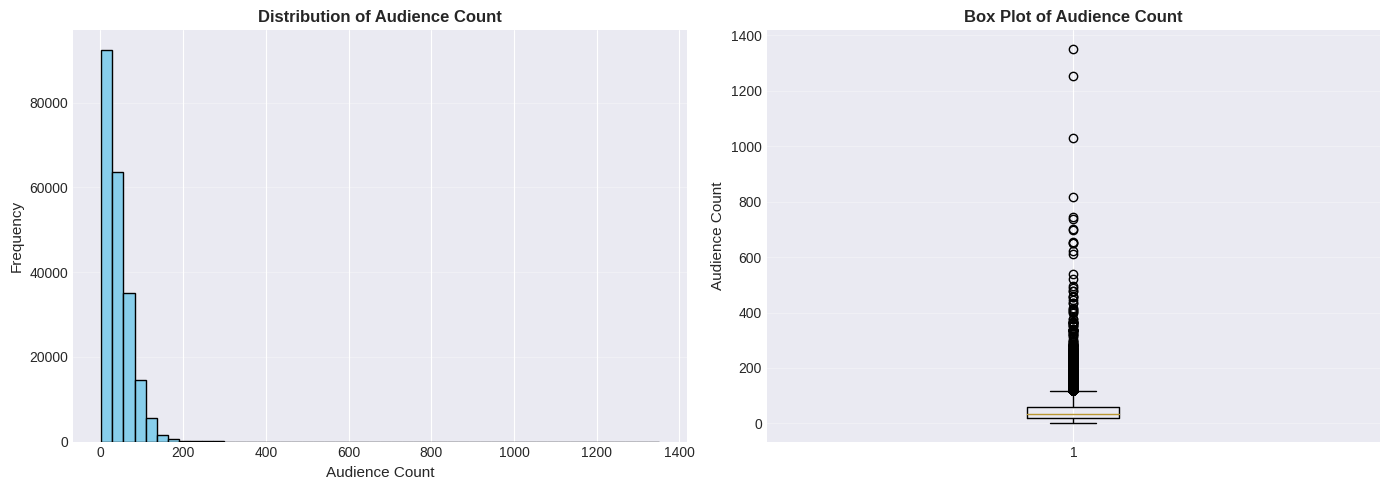

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(visits['audience_count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Audience Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Audience Count', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(visits['audience_count'], vert=True)
axes[1].set_ylabel('Audience Count', fontsize=11)
axes[1].set_title('Box Plot of Audience Count', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

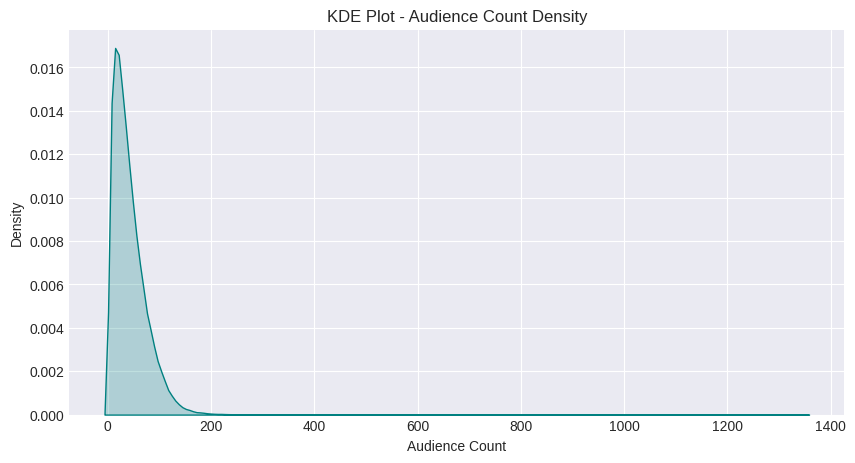

In [12]:
# Kernel Density Estimate Plot
plt.figure(figsize=(10,5))
sns.kdeplot(visits['audience_count'], fill=True, color='teal')
plt.title("KDE Plot - Audience Count Density")
plt.xlabel("Audience Count")
plt.ylabel("Density")
plt.show()

In [13]:
# Converting show_date column to datetime format
visits['show_date'] = pd.to_datetime(visits['show_date'])

# Creating time-based features
visits['day_of_week'] = visits['show_date'].dt.day_name()
visits['day_num'] = visits['show_date'].dt.dayofweek   # Monday=0, Sunday=6
visits['month'] = visits['show_date'].dt.month
visits['month_name'] = visits['show_date'].dt.strftime('%B')

print("New time-based features added:")
print(visits[['show_date', 'day_num', 'month']].head())

New time-based features added:
   show_date  day_num  month
0 2023-01-13        4      1
1 2023-01-14        5      1
2 2023-01-15        6      1
3 2023-01-16        0      1
4 2023-01-18        2      1


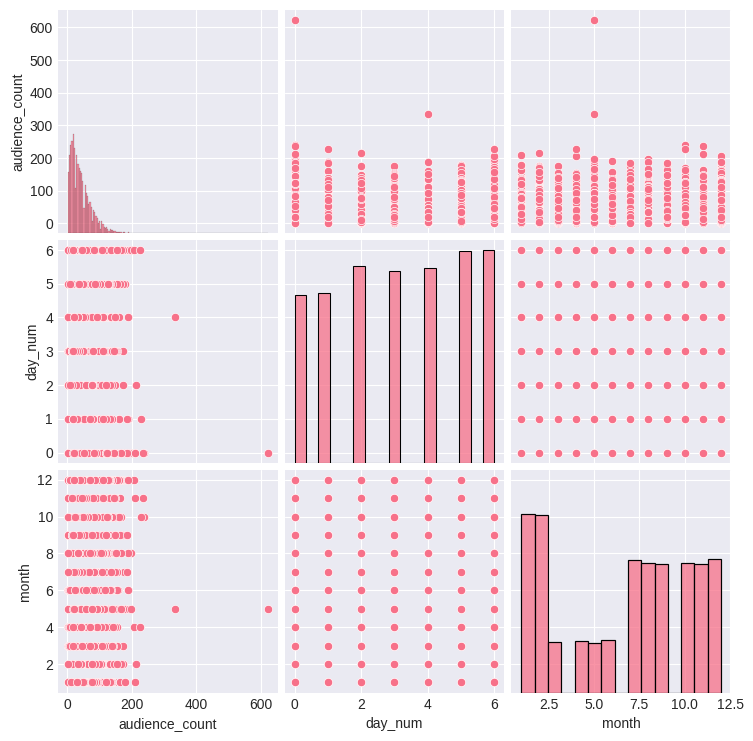

In [14]:
# Sampling a small portion to avoid slow plotting
sample = visits.sample(10000)

# Now pairplot works because features exist
sns.pairplot(sample[['audience_count', 'day_num', 'month']])
plt.show()

In [15]:
print(f"Mean: {visits['audience_count'].mean():.2f}")
print(f"Median: {visits['audience_count'].median():.2f}")
print(f"Std Dev: {visits['audience_count'].std():.2f}")
print(f"Min: {visits['audience_count'].min()}")
print(f"Max: {visits['audience_count'].max()}")

Mean: 41.62
Median: 34.00
Std Dev: 32.83
Min: 2
Max: 1350


In [16]:
visits['show_date'] = pd.to_datetime(visits['show_date'])
visits['day_of_week'] = visits['show_date'].dt.day_name()
visits['day_num'] = visits['show_date'].dt.dayofweek

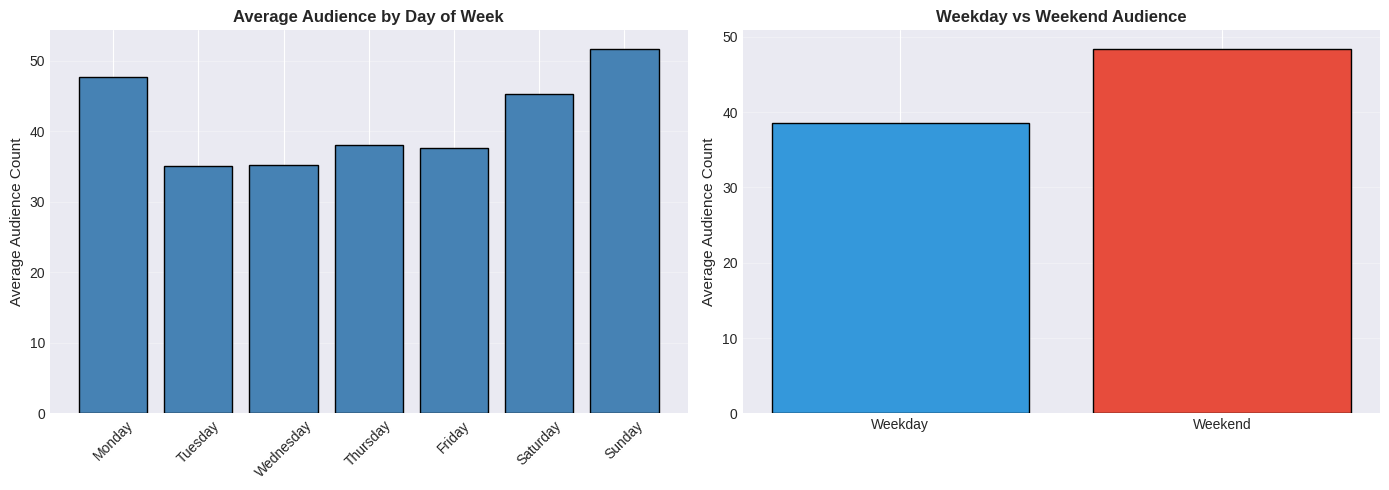

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = visits.groupby('day_of_week')['audience_count'].mean().reindex(day_order)
axes[0].bar(range(7), day_avg.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_order, rotation=45)
axes[0].set_ylabel('Average Audience Count', fontsize=11)
axes[0].set_title('Average Audience by Day of Week', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Weekend vs Weekday
visits['is_weekend'] = visits['day_num'] >= 5
weekend_avg = visits.groupby('is_weekend')['audience_count'].mean()
axes[1].bar(['Weekday', 'Weekend'], weekend_avg.values, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_ylabel('Average Audience Count', fontsize=11)
axes[1].set_title('Weekday vs Weekend Audience', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

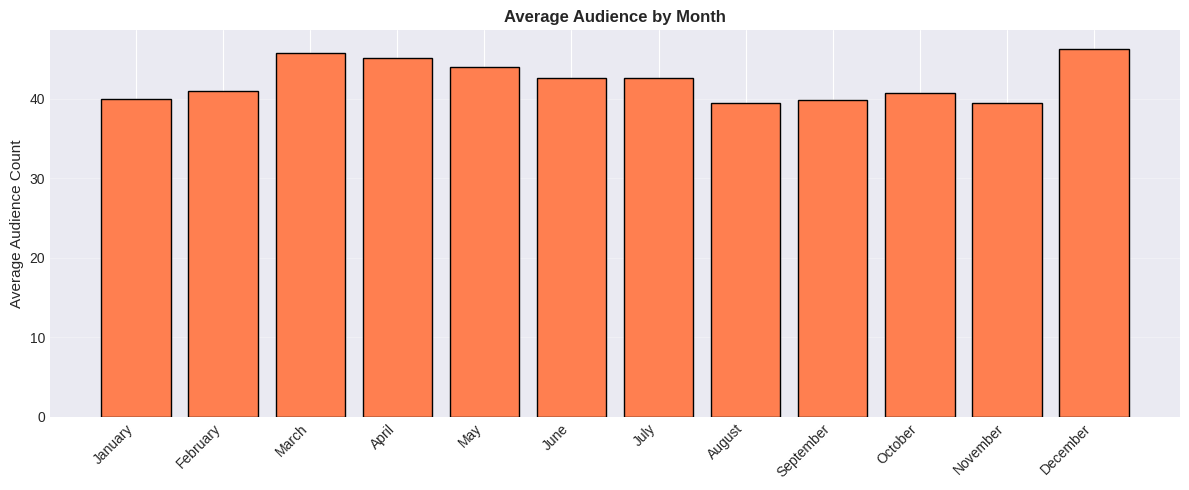

In [18]:
visits['month'] = visits['show_date'].dt.month
visits['month_name'] = visits['show_date'].dt.strftime('%B')

fig, ax = plt.subplots(figsize=(12, 5))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_avg = visits.groupby('month_name')['audience_count'].mean().reindex(month_order)
ax.bar(range(len(month_avg)), month_avg.values, color='coral', edgecolor='black')
ax.set_xticks(range(len(month_avg)))
ax.set_xticklabels(month_order, rotation=45, ha='right')
ax.set_ylabel('Average Audience Count', fontsize=11)
ax.set_title('Average Audience by Month', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

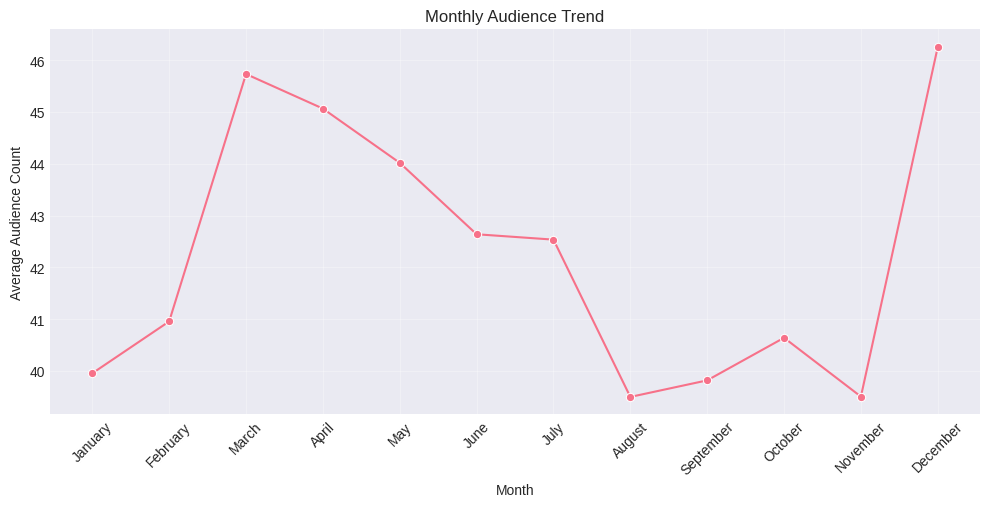

In [19]:
# Average audience count per month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

month_avg = visits.groupby('month_name')['audience_count'].mean().reindex(month_order)

plt.figure(figsize=(12,5))
sns.lineplot(x=month_order, y=month_avg.values, marker='o')
plt.title("Monthly Audience Trend")
plt.xlabel("Month")
plt.ylabel("Average Audience Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

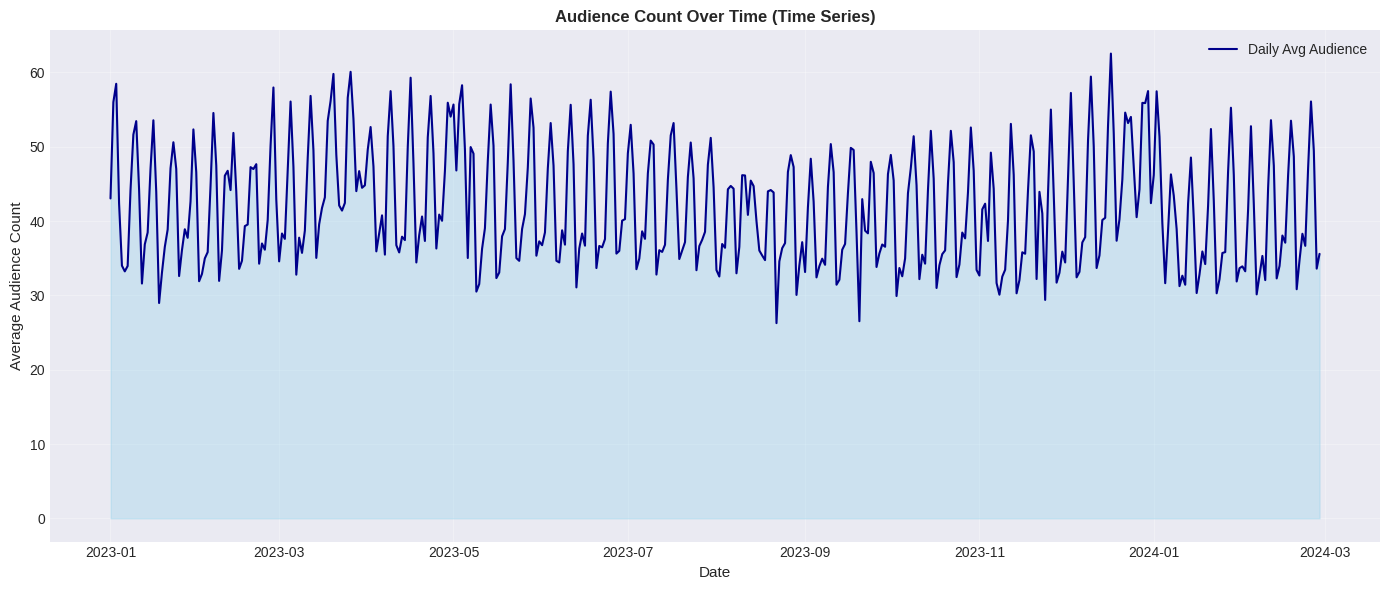

In [20]:
visits_sorted = visits.sort_values('show_date')
daily_avg = visits_sorted.groupby('show_date')['audience_count'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_avg.index, daily_avg.values, color='darkblue', linewidth=1.5, label='Daily Avg Audience')
ax.fill_between(daily_avg.index, daily_avg.values, alpha=0.3, color='skyblue')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Average Audience Count', fontsize=11)
ax.set_title('Audience Count Over Time (Time Series)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

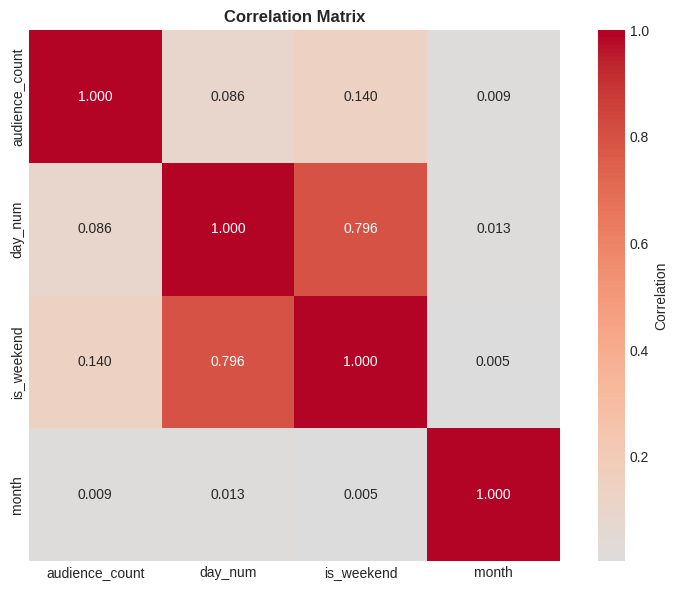

In [21]:
visits_numeric = visits[['audience_count', 'day_num', 'is_weekend', 'month']].copy()

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = visits_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print(" First 5 Rows:")
display(bookings_bn.head())

print("\nInfo:")
bookings_bn.info()

print("\nMissing Values:")
print(bookings_bn.isnull().sum())

print("\nSummary Statistics:")
display(bookings_bn.describe())

 First 5 Rows:


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB

Missing Values:
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

Summary Statistics:


,tickets_booked
count,68336.000000
mean,4.425808
std,4.808945
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,100.000000


Time-based features added.


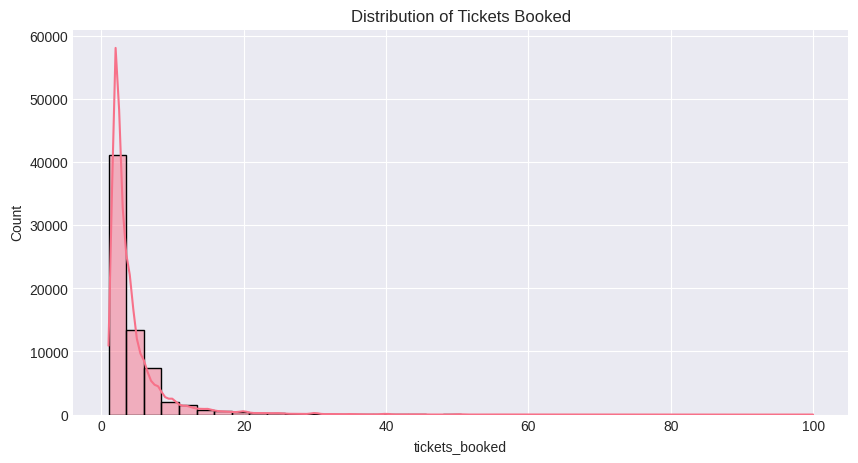

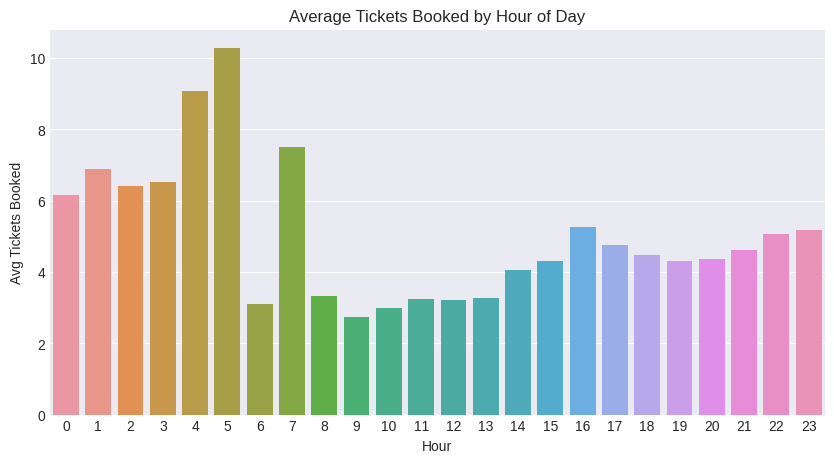

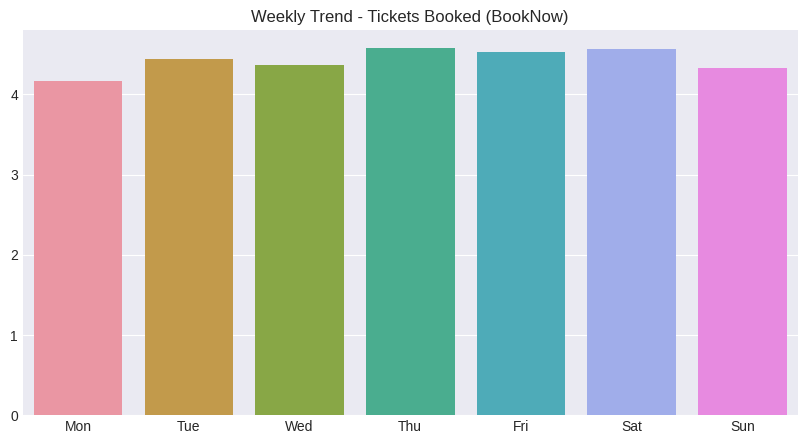

In [23]:
bookings_bn["show_datetime"] = pd.to_datetime(bookings_bn["show_datetime"])
bookings_bn["date"] = bookings_bn["show_datetime"].dt.date
bookings_bn["hour"] = bookings_bn["show_datetime"].dt.hour
bookings_bn["day_num"] = bookings_bn["show_datetime"].dt.dayofweek
bookings_bn["month"] = bookings_bn["show_datetime"].dt.month

print("Time-based features added.")


plt.figure(figsize=(10,5))
sns.histplot(bookings_bn['tickets_booked'], bins=40, kde=True)
plt.title("Distribution of Tickets Booked")
plt.show()


plt.figure(figsize=(10,5))
sns.barplot(x=bookings_bn.groupby("hour")["tickets_booked"].mean().index,
            y=bookings_bn.groupby("hour")["tickets_booked"].mean().values)
plt.title("Average Tickets Booked by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Tickets Booked")
plt.show()


day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
avg_week = bookings_bn.groupby("day_num")["tickets_booked"].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=day_labels, y=avg_week.values)
plt.title("Weekly Trend - Tickets Booked (BookNow)")
plt.show()

 First Rows:


,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13



 Summary:


,tickets_sold
count,1.641966e+06
mean,4.987345e+00
std,5.234901e+00
min,1.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,6.000000e+00
max,1.000000e+02



 Missing Values:
cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64


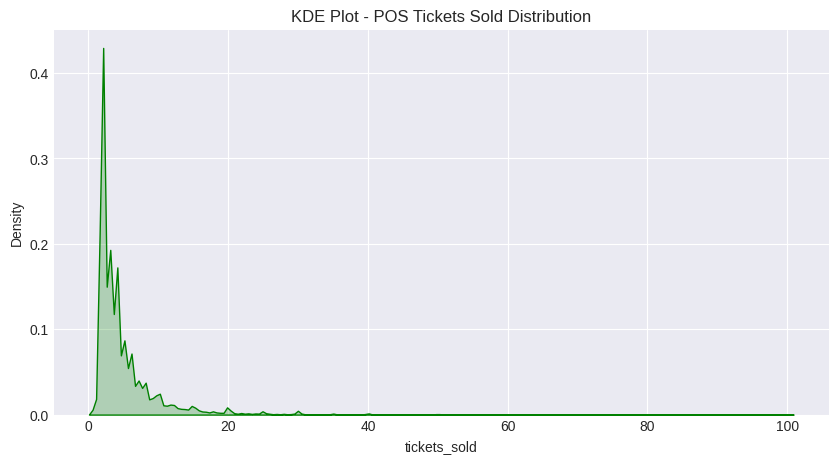

In [24]:
print(" First Rows:")
display(bookings_pos.head())

print("\n Summary:")
display(bookings_pos.describe())

print("\n Missing Values:")
print(bookings_pos.isnull().sum())



bookings_pos["show_datetime"] = pd.to_datetime(bookings_pos["show_datetime"])
bookings_pos["hour"] = bookings_pos["show_datetime"].dt.hour
bookings_pos["day_num"] = bookings_pos["show_datetime"].dt.dayofweek

plt.figure(figsize=(10,5))
sns.kdeplot(bookings_pos["tickets_sold"], fill=True, color='green')
plt.title("KDE Plot - POS Tickets Sold Distribution")
plt.show()


 BookNow Theater Info:


,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515



 Unique Cities: 103

 Missing Values:
book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64


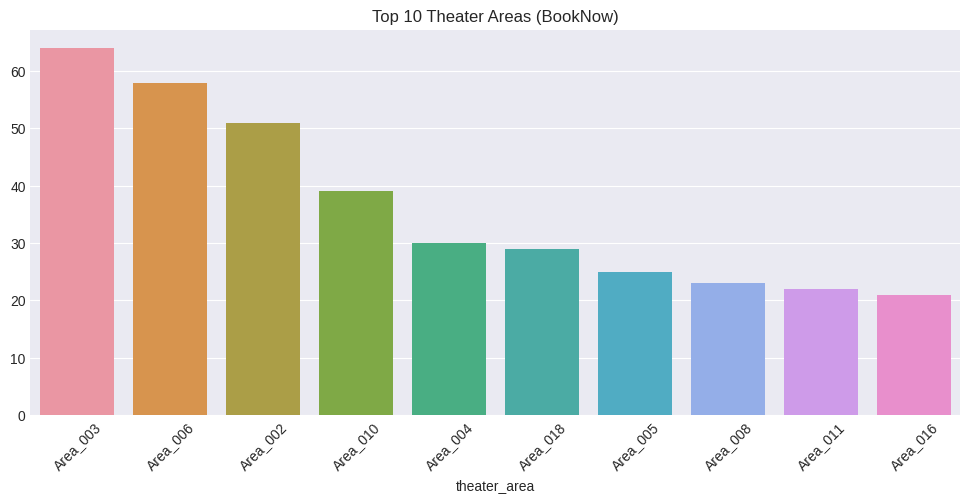

In [25]:
print("\n BookNow Theater Info:")
display(theaters_bn.head())

print("\n Unique Cities:", theaters_bn['theater_area'].nunique())
print("\n Missing Values:")
print(theaters_bn.isnull().sum())



plt.figure(figsize=(12,5))
top_cities = theaters_bn['theater_area'].value_counts().head(10)

sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top 10 Theater Areas (BookNow)")
plt.xticks(rotation=45)
plt.show()

**DATA PREPARATION**

Merge booking data

In [26]:
bookings_bn["show_date"] = pd.to_datetime(bookings_bn["show_datetime"]).dt.normalize()
bookings_pos["show_date"] = pd.to_datetime(bookings_pos["show_datetime"]).dt.normalize()
bookings_pos = bookings_pos.merge(map_ids, on="cine_theater_id", how="left")

bn_daily = bookings_bn.groupby(["book_theater_id", "show_date"])["tickets_booked"].sum().reset_index()
pos_daily = bookings_pos.groupby(["book_theater_id", "show_date"])["tickets_sold"].sum().reset_index()



Merge with visits

In [27]:
df = visits.copy()
df = df.merge(bn_daily, on=["book_theater_id", "show_date"], how="left")
df = df.merge(pos_daily, on=["book_theater_id", "show_date"], how="left")

Fill missing values

In [28]:
df[["tickets_booked", "tickets_sold"]] = df[["tickets_booked", "tickets_sold"]].fillna(0)
df["total_tickets"] = df["tickets_booked"] + df["tickets_sold"]

print(f"Shape after merging: {df.shape}")

Shape after merging: (214046, 11)


In [29]:
df = df.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)

In [30]:
df["day_of_week"] = df["show_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["month"] = df["show_date"].dt.month
df["day_of_month"] = df["show_date"].dt.day
df["week_of_year"] = df["show_date"].dt.isocalendar().week.astype(int)

statistical feature engineering

In [31]:
global_avg = df['audience_count'].mean()
theater_means = df.groupby("book_theater_id")["audience_count"].mean()
df['avg_theater_audience'] = df['book_theater_id'].map(theater_means).fillna(global_avg)

Audience count from the previous week using lag

In [32]:
for lag in [1, 7]:
    df[f"aud_lag_{lag}"] = df.groupby("book_theater_id")["audience_count"].shift(lag)

rolling mean

In [33]:
df["roll_mean_7"] = df.groupby("book_theater_id")["audience_count"].shift(1).rolling(7, min_periods=1).mean()

In [34]:
lag_cols = [c for c in df.columns if "lag" in c or "roll_" in c]
for col in lag_cols:
    df[col] = df[col].fillna(df['avg_theater_audience'])

print("Features created")
print(f"Total features: {len(df.columns)}")

Features created
Total features: 17


In [35]:
features = [
    'total_tickets', 'day_of_week', 'is_weekend', 'month', 'day_of_month',
    'week_of_year', 'avg_theater_audience', 'aud_lag_1', 'aud_lag_7', 'roll_mean_7'
]

In [36]:
X = df[features].copy()
y = df['audience_count'].copy()

In [37]:
print(f"\nFeatures selected: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


Features selected: ['total_tickets', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'week_of_year', 'avg_theater_audience', 'aud_lag_1', 'aud_lag_7', 'roll_mean_7']
X shape: (214046, 10)
y shape: (214046,)


In [38]:
print("Missing values in features:")
print(X.isnull().sum())

Missing values in features:
total_tickets           0
day_of_week             0
is_weekend              0
month                   0
day_of_month            0
week_of_year            0
avg_theater_audience    0
aud_lag_1               0
aud_lag_7               0
roll_mean_7             0
dtype: int64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (171236, 10)
X_test shape: (42810, 10)
y_train shape: (171236,)
y_test shape: (42810,)


In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

Features scaled using StandardScaler


In [41]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

print("Random Forest trained")

Random Forest trained


In [42]:
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_pred_train))
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_mae_test = mean_absolute_error(y_test, rf_pred_test)
rf_r2_test = r2_score(y_test, rf_pred_test)

print(f"Random Forest Performance:")
print(f"  Train RMSE: {rf_rmse_train:.4f}")
print(f"  Test RMSE: {rf_rmse_test:.4f}")
print(f"  Test MAE: {rf_mae_test:.4f}")
print(f"  Test R(square) Score: {rf_r2_test:.4f}")

Random Forest Performance:
  Train RMSE: 21.8231
  Test RMSE: 22.3185
  Test MAE: 15.1183
  Test R(square) Score: 0.5248


In [43]:
!pip install optuna

In [44]:
import optuna
from optuna.pruners import MedianPruner

In [45]:

print("TUNING LIGHTGBM ")


def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10),
    }
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    return rmse

study_lgb = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_lgb.optimize(objective_lgb, n_trials=15, show_progress_bar=True)

best_params_lgb = study_lgb.best_params
print(f"\n LightGBM Tuning Completed")
print(f"Best parameters: {best_params_lgb}")
print(f"Best RMSE: {study_lgb.best_value:.4f}")

[I 2025-11-29 12:56:51,298] A new study created in memory with name: no-name-0083274b-e859-4eb7-946f-175804276239


TUNING LIGHTGBM 


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-29 12:56:53,155] Trial 0 finished with value: 22.092124544188717 and parameters: {'n_estimators': 231, 'max_depth': 13, 'learning_rate': 0.041724601167771276, 'num_leaves': 27, 'lambda_l1': 3.392825207164731, 'lambda_l2': 8.055195682839832}. Best is trial 0 with value: 22.092124544188717.
[I 2025-11-29 12:56:55,186] Trial 1 finished with value: 22.07148990308043 and parameters: {'n_estimators': 283, 'max_depth': 6, 'learning_rate': 0.0485625249122027, 'num_leaves': 42, 'lambda_l1': 9.644567532903999, 'lambda_l2': 5.22422211853394}. Best is trial 1 with value: 22.07148990308043.
[I 2025-11-29 12:56:56,342] Trial 2 finished with value: 22.049631523357792 and parameters: {'n_estimators': 107, 'max_depth': 12, 'learning_rate': 0.06071048768100359, 'num_leaves': 49, 'lambda_l1': 0.2904496713268217, 'lambda_l2': 5.950739349840075}. Best is trial 2 with value: 22.049631523357792.
[I 2025-11-29 12:56:57,841] Trial 3 finished with value: 21.948687838222224 and parameters: {'n_estimat

In [46]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08888000895339292,
    num_leaves=41,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
lgb_pred_train = lgb_model.predict(X_train)
lgb_pred_test = lgb_model.predict(X_test)

print("LightGBM trained")

LightGBM trained


In [47]:
X_train

,total_tickets,day_of_week,is_weekend,month,day_of_month,week_of_year,avg_theater_audience,aud_lag_1,aud_lag_7,roll_mean_7
142915,12.0,6,1,1,14,2,34.652720,38.0,48.000000,31.714286
1057,0.0,4,0,9,1,35,20.486339,16.0,10.000000,19.714286
82947,0.0,4,0,7,21,29,19.958115,10.0,8.000000,24.857143
28056,28.0,5,1,11,11,45,60.704663,38.0,38.000000,57.428571
35354,0.0,3,0,7,6,27,45.894737,68.0,45.894737,55.000000
...,...,...,...,...,...,...,...,...,...,...
119879,0.0,2,0,1,25,4,58.230769,36.0,90.000000,53.714286
103694,0.0,4,0,9,22,38,20.872818,18.0,16.000000,12.285714
131932,2.0,6,1,8,20,33,52.107884,74.0,86.000000,54.285714
146867,0.0,5,1,12,2,48,19.605911,18.0,28.000000,16.857143


In [48]:
lgb_rmse_train = np.sqrt(mean_squared_error(y_train, lgb_pred_train))
lgb_rmse_test = np.sqrt(mean_squared_error(y_test, lgb_pred_test))
lgb_mae_test = mean_absolute_error(y_test, lgb_pred_test)
lgb_r2_test = r2_score(y_test, lgb_pred_test)

print(f"LightGBM Performance:")
print(f"  Train RMSE: {lgb_rmse_train:.4f}")
print(f"  Test RMSE: {lgb_rmse_test:.4f}")
print(f"  Test MAE: {lgb_mae_test:.4f}")
print(f"  Test R(square) Score: {lgb_r2_test:.4f}")

LightGBM Performance:
  Train RMSE: 21.2701
  Test RMSE: 21.9171
  Test MAE: 14.8253
  Test R(square) Score: 0.5418


In [49]:
print("TUNING XGBOOST ")

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-8, 10),
        'alpha': trial.suggest_float('alpha', 1e-8, 10),
    }
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    return rmse

study_xgb = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_xgb.optimize(objective_xgb, n_trials=15, show_progress_bar=True)

best_params_xgb = study_xgb.best_params
print(f"\n XGBoost Tuning Complete")
print(f"Best parameters: {best_params_xgb}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")

[I 2025-11-29 12:57:17,063] A new study created in memory with name: no-name-d1505fa6-c9e0-434d-af23-891df8a88f99


TUNING XGBOOST 


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-29 12:57:20,644] Trial 0 finished with value: 21.676538741908004 and parameters: {'n_estimators': 294, 'max_depth': 9, 'learning_rate': 0.04237960148904175, 'subsample': 0.7569037288586313, 'colsample_bytree': 0.9329997883037672, 'lambda': 5.553993092325883, 'alpha': 2.144793721526512}. Best is trial 0 with value: 21.676538741908004.
[I 2025-11-29 12:57:23,112] Trial 1 finished with value: 22.290773357203314 and parameters: {'n_estimators': 294, 'max_depth': 6, 'learning_rate': 0.011614760554797404, 'subsample': 0.6402362877845177, 'colsample_bytree': 0.938445430928609, 'lambda': 9.428501965998786, 'alpha': 8.21772561521491}. Best is trial 0 with value: 21.676538741908004.
[I 2025-11-29 12:57:24,721] Trial 2 finished with value: 21.832486019636356 and parameters: {'n_estimators': 128, 'max_depth': 9, 'learning_rate': 0.054477659861445496, 'subsample': 0.9484978130493328, 'colsample_bytree': 0.9290561610153343, 'lambda': 9.046176788242914, 'alpha': 7.3421680722642995}. Best i

In [50]:
xgb_model = xgb.XGBRegressor(
    n_estimators=136,
    max_depth=10,
    learning_rate=0.09943773961978927,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test = xgb_model.predict(X_test)

print("XGBoost trained")

XGBoost trained


In [51]:
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_pred_train))
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_mae_test = mean_absolute_error(y_test, xgb_pred_test)
xgb_r2_test = r2_score(y_test, xgb_pred_test)

print(f"XGBoost Performance:")
print(f"  Train RMSE: {xgb_rmse_train:.4f}")
print(f"  Test RMSE: {xgb_rmse_test:.4f}")
print(f"  Test MAE: {xgb_mae_test:.4f}")
print(f"  Test R(square) Score: {xgb_r2_test:.4f}")

XGBoost Performance:
  Train RMSE: 17.0062
  Test RMSE: 21.7995
  Test MAE: 14.6852
  Test R(square) Score: 0.5467


In [52]:

print("MODEL COMPARISON SUMMARY:")


comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM', 'XGBoost'],
    'Train RMSE': [rf_rmse_train, lgb_rmse_train, xgb_rmse_train],
    'Test RMSE': [rf_rmse_test, lgb_rmse_test, xgb_rmse_test],
    'Test MAE': [rf_mae_test, lgb_mae_test, xgb_mae_test],
    'Test R(square) Score': [rf_r2_test, lgb_r2_test, xgb_r2_test]
})

print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY:
        Model  Train RMSE  Test RMSE  Test MAE  Test R(square) Score
Random Forest   21.823081  22.318530 15.118332              0.524820
     LightGBM   21.270062  21.917072 14.825331              0.541761
      XGBoost   17.006203  21.799541 14.685175              0.546663


Visualize Model Comparison

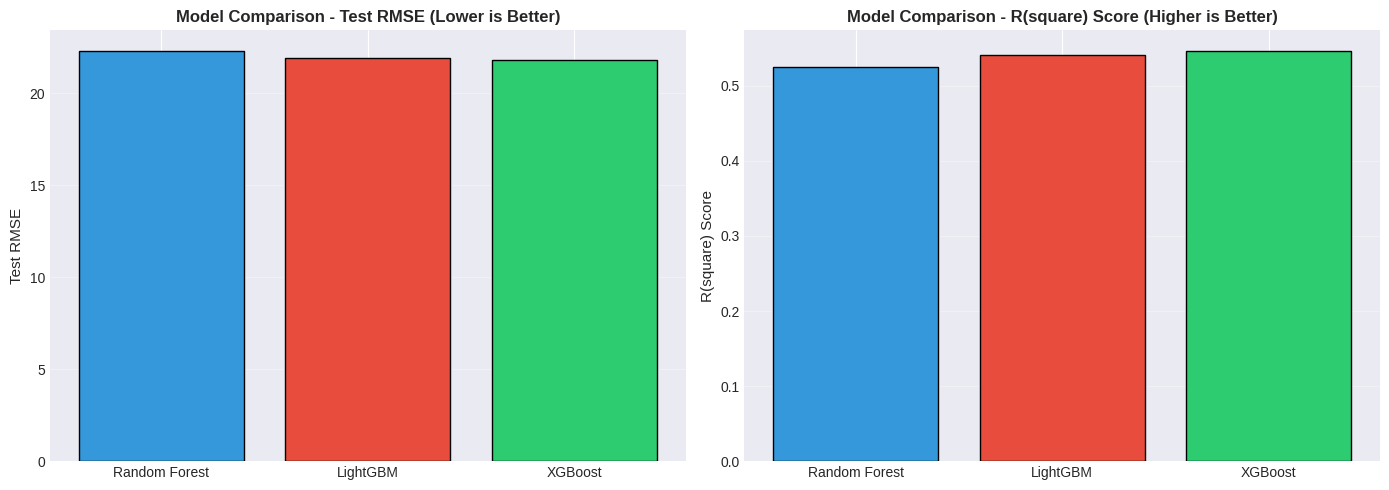

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Comparison
axes[0].bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Test RMSE', fontsize=11)
axes[0].set_title('Model Comparison - Test RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# R(square) Score Comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test R(square) Score'], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_ylabel('R(square) Score', fontsize=11)
axes[1].set_title('Model Comparison - R(square) Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Feature Importance - LightGBM

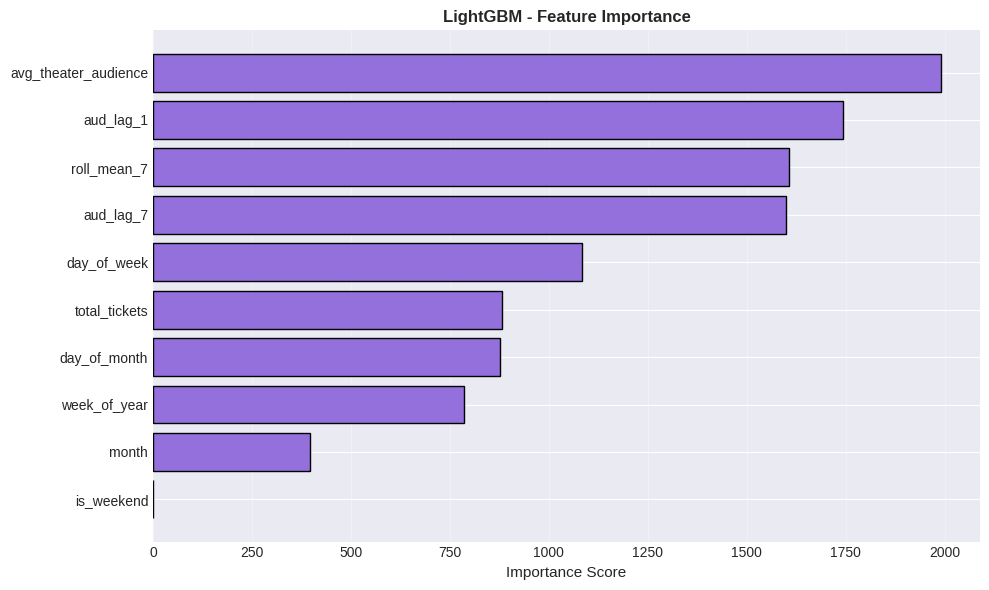

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_df = pd.DataFrame({
    'feature': features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True)

ax.barh(importance_df['feature'], importance_df['importance'], color='mediumpurple', edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('LightGBM - Feature Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance - XGBoost

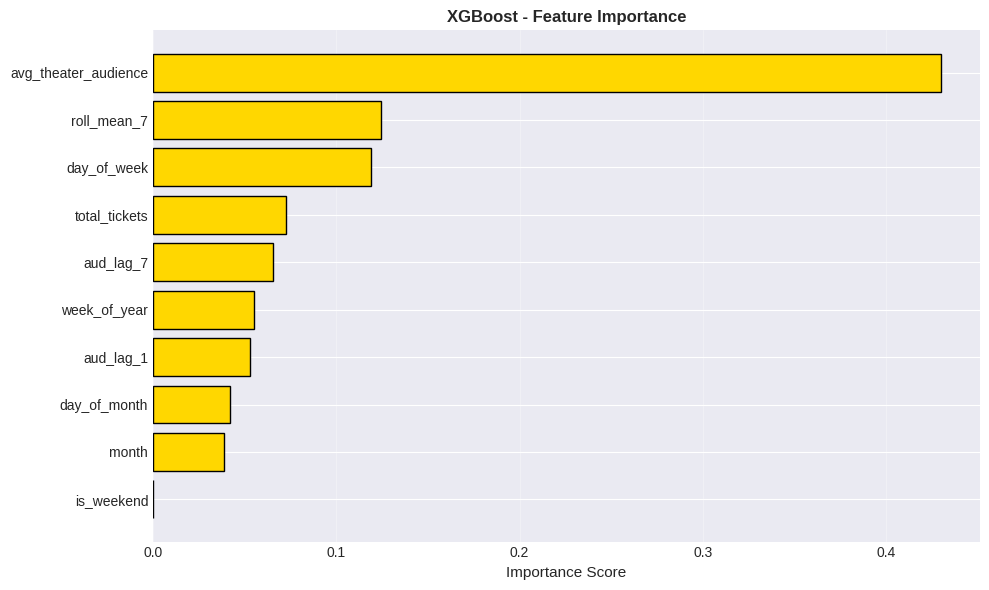

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
xgb_importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

ax.barh(xgb_importance_df['feature'], xgb_importance_df['importance'], color='gold', edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Prediction vs Actual (LightGBM)

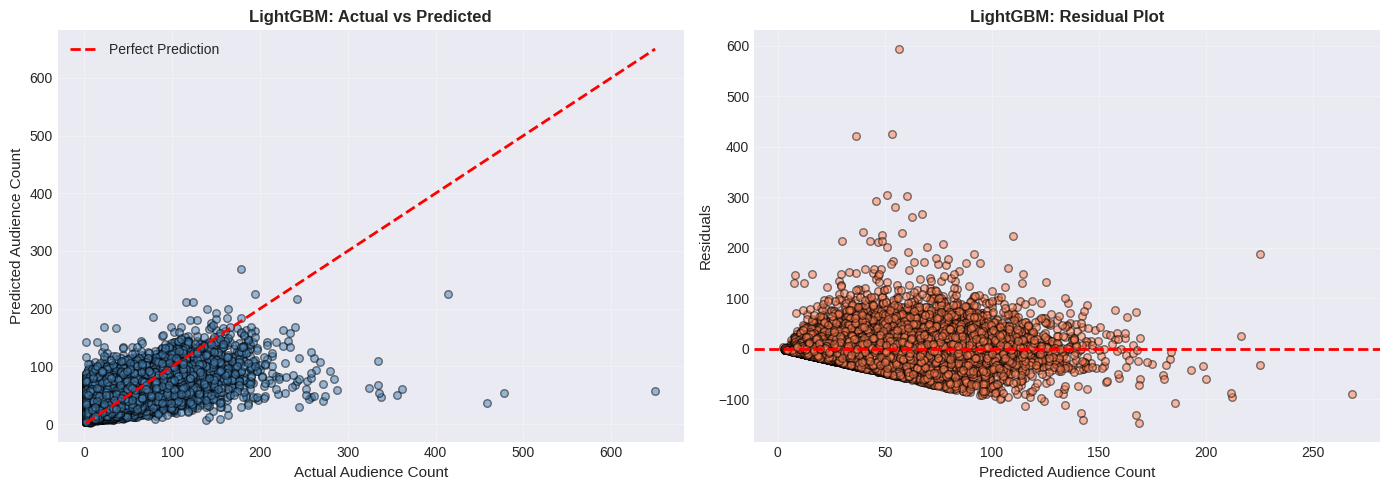

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Scatter plot
axes[0].scatter(y_test, lgb_pred_test, alpha=0.5, color='steelblue', edgecolor='black', s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Audience Count', fontsize=11)
axes[0].set_ylabel('Predicted Audience Count', fontsize=11)
axes[0].set_title('LightGBM: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - lgb_pred_test
axes[1].scatter(lgb_pred_test, residuals, alpha=0.5, color='coral', edgecolor='black', s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Audience Count', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('LightGBM: Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 Ensemble Prediction

In [57]:
 # Weighted average of all models
ensemble_pred = (0.4 * lgb_pred_test + 0.4 * xgb_pred_test + 0.2 * rf_pred_test)

ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_r2 = r2_score(y_test, ensemble_pred)

print(f"Ensemble Model Performance:")
print(f"  Test RMSE: {ensemble_rmse:.4f}")
print(f"  Test MAE: {ensemble_mae:.4f}")
print(f"  Test R(square) Score: {ensemble_r2:.4f}")

Ensemble Model Performance:
  Test RMSE: 21.7199
  Test MAE: 14.6933
  Test R(square) Score: 0.5500


In [58]:
final_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM', 'XGBoost', 'Ensemble'],
    'Test RMSE': [rf_rmse_test, lgb_rmse_test, xgb_rmse_test, ensemble_rmse],
    'Test MAE': [rf_mae_test, lgb_mae_test, xgb_mae_test, ensemble_mae],
    'Test R(square) Score': [rf_r2_test, lgb_r2_test, xgb_r2_test, ensemble_r2]
})


print("FINAL MODEL COMPARISON WITH ENSEMBLE")
print(final_comparison.to_string(index=False))

FINAL MODEL COMPARISON WITH ENSEMBLE
        Model  Test RMSE  Test MAE  Test R(square) Score
Random Forest  22.318530 15.118332              0.524820
     LightGBM  21.917072 14.825331              0.541761
      XGBoost  21.799541 14.685175              0.546663
     Ensemble  21.719947 14.693338              0.549967


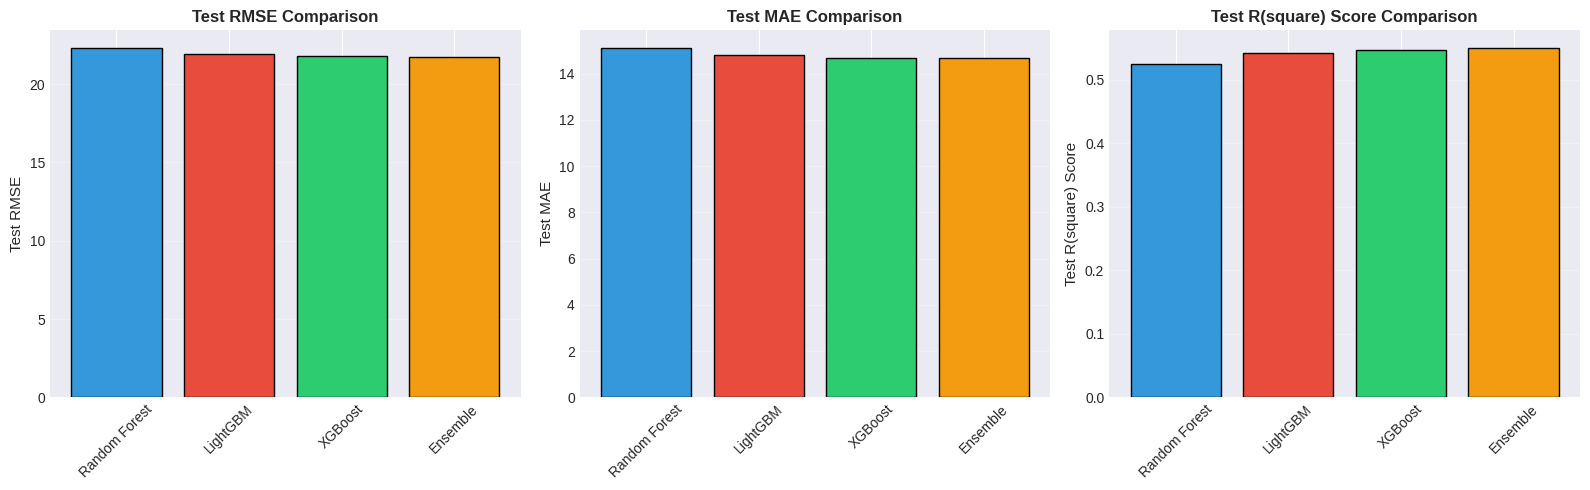

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE
axes[0].bar(final_comparison['Model'], final_comparison['Test RMSE'], 
            color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[0].set_ylabel('Test RMSE', fontsize=11)
axes[0].set_title('Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# MAE
axes[1].bar(final_comparison['Model'], final_comparison['Test MAE'], 
            color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[1].set_ylabel('Test MAE', fontsize=11)
axes[1].set_title('Test MAE Comparison', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# R(square) Score
axes[2].bar(final_comparison['Model'], final_comparison['Test R(square) Score'], 
            color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[2].set_ylabel('Test R(square) Score', fontsize=11)
axes[2].set_title('Test R(square) Score Comparison', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
sample_sub = pd.read_csv(BASE_PATH + "sample_submission/sample_submission.csv")
print(f"Sample submission shape: {sample_sub.shape}")
print(f"Sample submission head:\n{sample_sub.head()}")

Sample submission shape: (38062, 2)
Sample submission head:
                      ID  audience_count
0  book_00001_2024-03-01               0
1  book_00001_2024-03-02               0
2  book_00001_2024-03-03               0
3  book_00001_2024-03-04               0
4  book_00001_2024-03-06               0


In [61]:
test = sample_sub.copy()
test[["book_theater_id", "show_date"]] = test["ID"].str.rsplit("_", n=1, expand=True)
test["show_date"] = pd.to_datetime(test["show_date"]).dt.normalize()
test["audience_count"] = np.nan

In [62]:
lgb_model

LGBMRegressor(learning_rate=0.08888000895339292, max_depth=8, n_estimators=300,
              n_jobs=-1, num_leaves=41, random_state=42, verbose=-1)

In [63]:
if "ID" in visits.columns:
    visits_clean = visits.drop(columns=["ID"])
else:
    visits_clean = visits.copy()

Combine train and test

In [64]:
full_df = pd.concat([visits_clean, test.drop(columns=["audience_count"])], 
                     ignore_index=True, sort=False)
full_df["show_date"] = pd.to_datetime(full_df["show_date"])

In [65]:
# Merge booking data
full_df = full_df.merge(bn_daily, on=["book_theater_id", "show_date"], how="left")
full_df = full_df.merge(pos_daily, on=["book_theater_id", "show_date"], how="left")

# Fill missing values
full_df[["tickets_booked", "tickets_sold"]] = full_df[["tickets_booked", "tickets_sold"]].fillna(0)
full_df["total_tickets"] = full_df["tickets_booked"] + full_df["tickets_sold"]

print(f"Full dataset shape: {full_df.shape}")

Full dataset shape: (252108, 12)


In [66]:
full_df = full_df.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)

# Calendar features
full_df["day_of_week"] = full_df["show_date"].dt.dayofweek
full_df["is_weekend"] = (full_df["day_of_week"] >= 5).astype(int)
full_df["month"] = full_df["show_date"].dt.month
full_df["day_of_month"] = full_df["show_date"].dt.day
full_df["week_of_year"] = full_df["show_date"].dt.isocalendar().week.astype(int)

# Theater baseline
global_avg_aud = full_df['audience_count'].mean()
avg_pop = full_df[full_df['audience_count'].notna()].groupby("book_theater_id")["audience_count"].mean()
full_df = full_df.merge(avg_pop.to_frame('avg_theater_audience'), 
                        left_on="book_theater_id", right_index=True, how="left")
full_df['avg_theater_audience'] = full_df['avg_theater_audience'].fillna(global_avg_aud)

# Lag features
for lag in [1, 7]:
    full_df[f"aud_lag_{lag}"] = full_df.groupby("book_theater_id")["audience_count"].shift(lag)

# Rolling mean
full_df["roll_mean_7"] = full_df.groupby("book_theater_id")["audience_count"].shift(1).rolling(7, min_periods=1).mean()

# Fill NaN values
lag_cols = [c for c in full_df.columns if "lag" in c or "roll_" in c]
for col in lag_cols:
    full_df[col] = full_df[col].fillna(full_df['avg_theater_audience'])
    full_df[col] = full_df[col].fillna(global_avg_aud)

print("Features added")

Features added


In [67]:
features = [
    'total_tickets', 'day_of_week', 'is_weekend', 'month', 'day_of_month',
    'week_of_year', 'avg_theater_audience', 'aud_lag_1', 'aud_lag_7', 'roll_mean_7'
]

# Get test data
test_df = full_df[full_df["audience_count"].isna()].reset_index(drop=True)
X_test_final = test_df[features].copy()

print(f"Test data shape: {X_test_final.shape}")
print(f"Features: {features}")

Test data shape: (38062, 10)
Features: ['total_tickets', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'week_of_year', 'avg_theater_audience', 'aud_lag_1', 'aud_lag_7', 'roll_mean_7']


In [68]:
lgb_pred_final = lgb_model.predict(X_test_final)
xgb_pred_final = xgb_model.predict(X_test_final)
rf_pred_final = rf_model.predict(X_test_final)


In [69]:
ensemble_pred_final = 0.4 * lgb_pred_final + 0.4 * xgb_pred_final + 0.2 * rf_pred_final
ensemble_pred_final = np.clip(ensemble_pred_final, 0, None)


In [70]:
#only using lgb

final_predictions = lgb_model.predict(X_test_final)
final_predictions = np.clip(final_predictions, 0, None)

In [71]:
submission_df = pd.DataFrame({
    "ID": test_df["ID"].values,
    "audience_count": ensemble_pred_final
})

In [72]:
print(submission_df.head(15))
print(f"\nShape: {submission_df.shape}")
print(f"\nPrediction Statistics:")
print(f"  Min: {submission_df['audience_count'].min():.2f}")
print(f"  Max: {submission_df['audience_count'].max():.2f}")
print(f"  Mean: {submission_df['audience_count'].mean():.2f}")
print(f"  Median: {submission_df['audience_count'].median():.2f}")

                       ID  audience_count
0   book_00001_2024-03-01       33.793337
1   book_00001_2024-03-02       51.960732
2   book_00001_2024-03-03       55.320450
3   book_00001_2024-03-04       52.064057
4   book_00001_2024-03-06       37.820508
5   book_00001_2024-03-07       33.901369
6   book_00001_2024-03-08       32.285793
7   book_00001_2024-03-09       51.642146
8   book_00001_2024-03-10       61.251340
9   book_00001_2024-03-11       53.261738
10  book_00001_2024-03-12       38.861662
11  book_00001_2024-03-13       40.176605
12  book_00001_2024-03-14       45.876032
13  book_00001_2024-03-15       45.600984
14  book_00001_2024-03-16       52.839328

Shape: (38062, 2)

Prediction Statistics:
  Min: 3.31
  Max: 171.06
  Mean: 42.66
  Median: 38.72


In [73]:
submission_df.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")
print(f"Total predictions: {len(submission_df)}")

submission.csv saved successfully!
Total predictions: 38062


In [74]:
!head /kaggle/working/submission.csv

ID,audience_count
book_00001_2024-03-01,33.79333743976947
book_00001_2024-03-02,51.96073182537963
book_00001_2024-03-03,55.32045022761483
book_00001_2024-03-04,52.06405736785665
book_00001_2024-03-06,37.82050759255859
book_00001_2024-03-07,33.9013693622342
book_00001_2024-03-08,32.28579297924234
book_00001_2024-03-09,51.64214567948824
book_00001_2024-03-10,61.25133967827606
